In [1]:
import sys, os
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from tensorflow import keras

from io_utils import DATA_PROCESSED, MODELS, REPORTS, load_json

shap.initjs()
np.random.seed(42)

c:\Miniconda3\envs\umum\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
selected_features = load_json('selected_features_v2.json')
label_names = {int(k): v for k, v in load_json('label_names_v2.json').items()}
best_model_info = load_json('best_model_info_v2.json')

model = keras.models.load_model(os.path.join(MODELS, 'best_model_v2.keras'))

test_df = pd.read_parquet(os.path.join(DATA_PROCESSED, 'test_v2.parquet'))
X_test = test_df[selected_features]
y_test = test_df['risk_class']

print(f'Model terbaik v2: {best_model_info["best_exp_id"]} ({best_model_info["config"]["description"]})')
print(f'Data uji untuk SHAP: {X_test.shape}')

Model terbaik v2: E6 (ANN + Dropout + Class Weight)
Data uji untuk SHAP: (133107, 34)


In [3]:
background = shap.sample(X_test, 100, random_state=42)

def predict_fn(x):
    return model.predict(np.asarray(x), verbose=0)

explainer = shap.Explainer(predict_fn, background, feature_names=selected_features)

sample_eval = shap.sample(X_test, 200, random_state=42)
shap_values = explainer(sample_eval)

print('SHAP values shape:', shap_values.values.shape)

PermutationExplainer explainer: 201it [05:20,  1.61s/it]                         

SHAP values shape: (200, 34, 3)


C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_9352\258687180.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


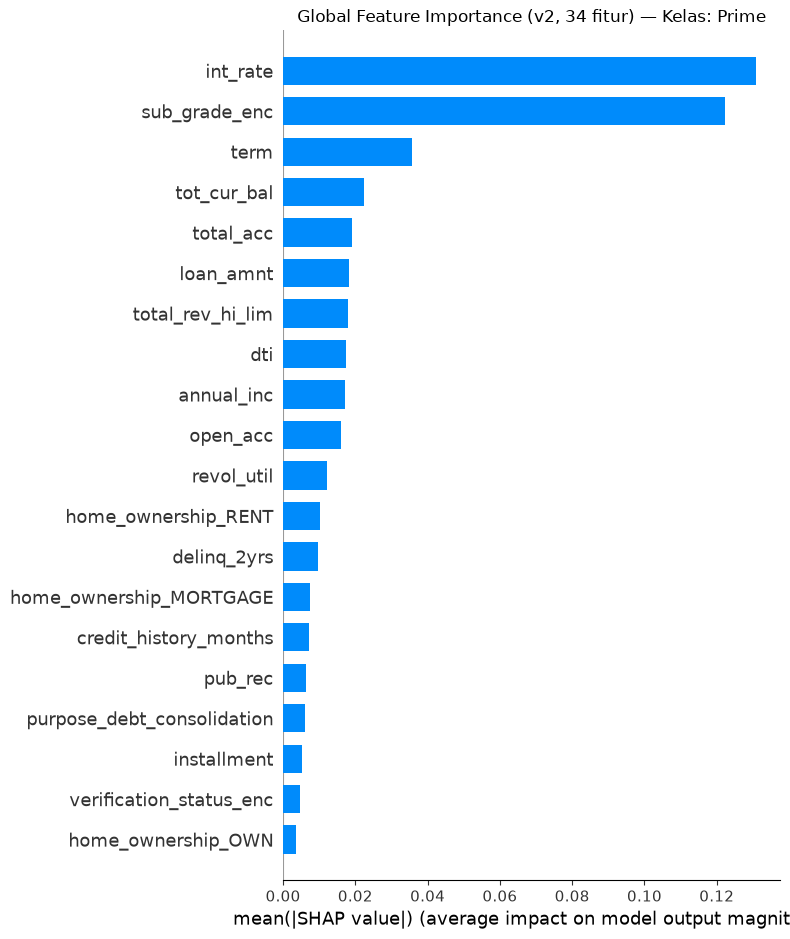

C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_9352\258687180.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


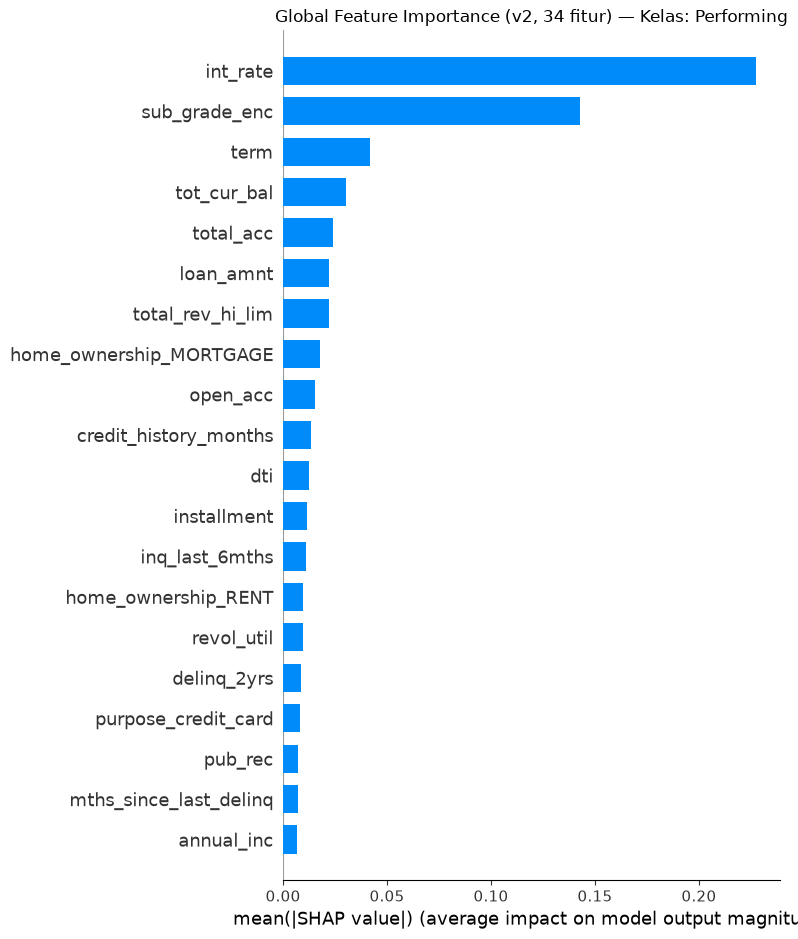

C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_9352\258687180.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


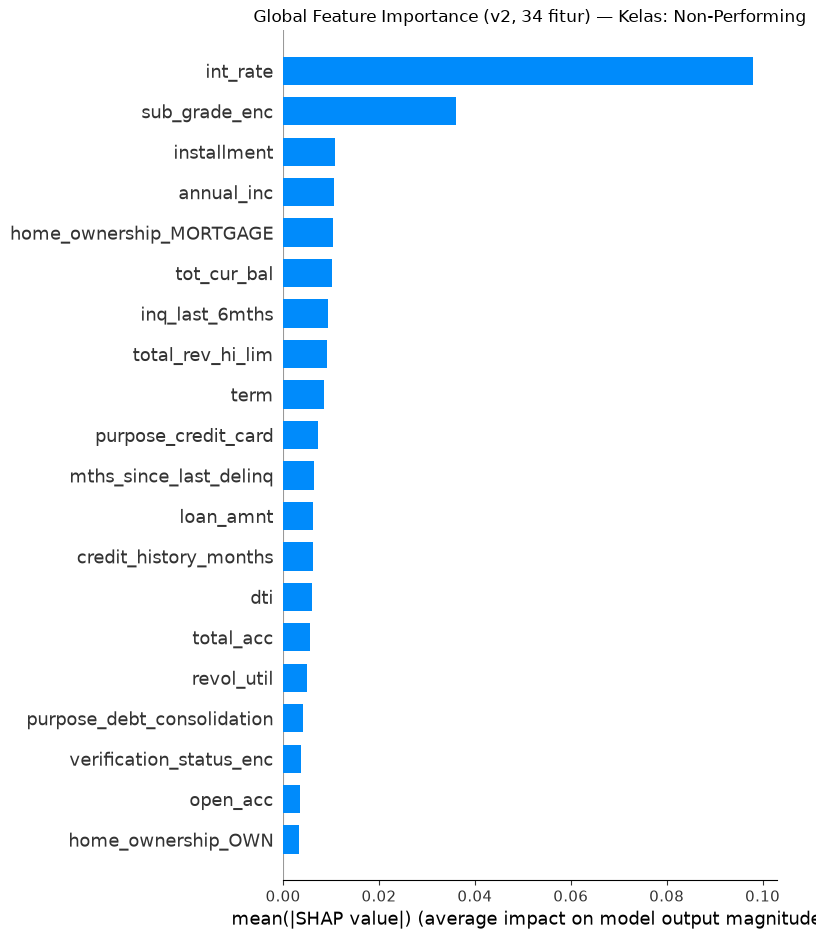

In [4]:
os.makedirs(os.path.join(REPORTS, 'shap_v2'), exist_ok=True)

for class_idx, class_name in label_names.items():
    plt.figure()
    shap.summary_plot(
        shap_values[:, :, class_idx].values, sample_eval,
        feature_names=selected_features, show=False, plot_type='bar',
    )
    plt.title(f'Global Feature Importance (v2, 34 fitur) — Kelas: {class_name}')
    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS, 'shap_v2', f'global_importance_{class_name}.png'), dpi=120)
    plt.show()

C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_9352\473011811.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


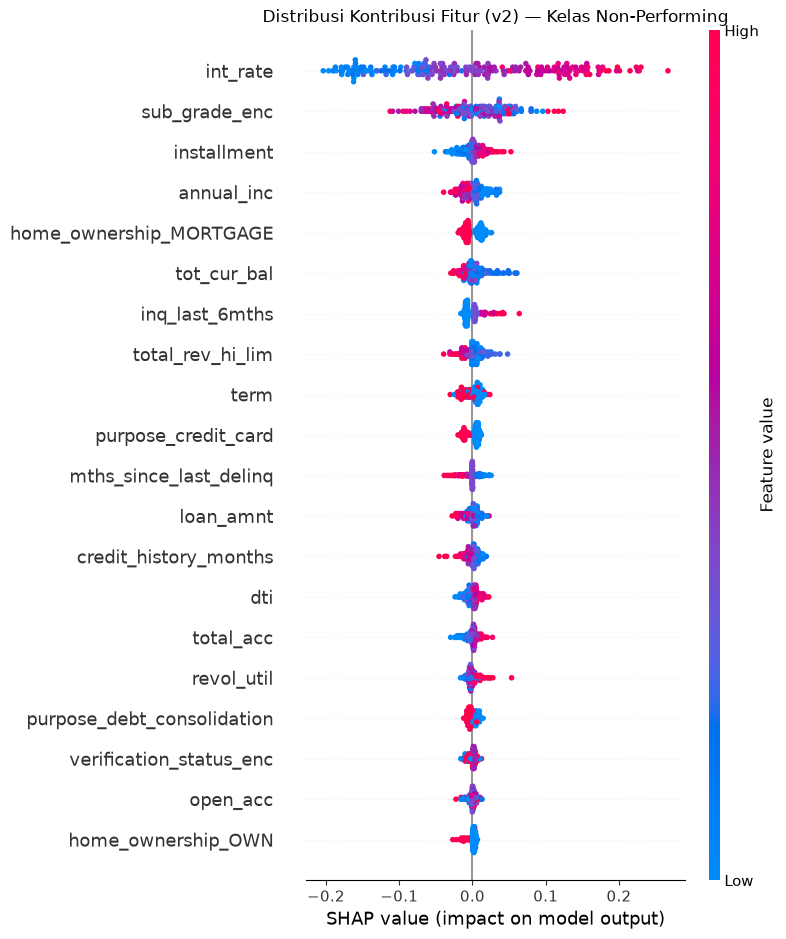

In [5]:
non_performing_idx = [k for k, v in label_names.items() if v == 'Non-Performing'][0]

plt.figure()
shap.summary_plot(
    shap_values[:, :, non_performing_idx].values, sample_eval,
    feature_names=selected_features, show=False,
)
plt.title('Distribusi Kontribusi Fitur (v2) — Kelas Non-Performing')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'shap_v2', 'beeswarm_non_performing.png'), dpi=120)
plt.show()

Prediksi nasabah index 0: Performing


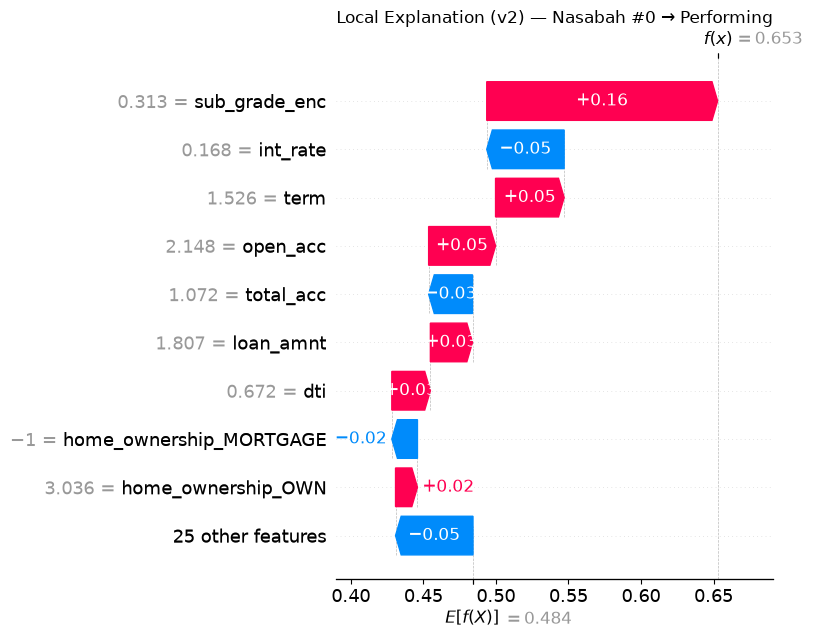

In [6]:
sample_idx = 0
customer = sample_eval.iloc[[sample_idx]]
pred_proba = model.predict(customer.values, verbose=0)[0]
pred_class = int(np.argmax(pred_proba))

print(f'Prediksi nasabah index {sample_idx}: {label_names[pred_class]}')

plt.figure()
shap.plots.waterfall(shap_values[sample_idx, :, pred_class], show=False)
plt.title(f'Local Explanation (v2) — Nasabah #{sample_idx} → {label_names[pred_class]}')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'shap_v2', f'local_explanation_{sample_idx}.png'), dpi=120)
plt.show()